# 5 · El techo estructural (por qué nadie pasa de ~0.6)

Ningún modelo — IForest, OCSVM, AE, DAE, VAE, ensemble — pasa de ~0.6. Cuando
familias tan distintas chocan contra el mismo número, el límite no está en el modelo sino
en la **señal**. Dos análisis independientes lo confirman.

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


soja  train: (6143, 65) | test anómalas: 251
maíz  train: (8082, 65) | test anómalas: 344


## 5.1 · ¿Se separan las anomalías en el espacio de features? (PCA)
Proyectamos las 54 features del **test** a 2D con PCA y coloreamos por etiqueta real, con
los ejes anotando **cuánta varianza explica cada componente**:

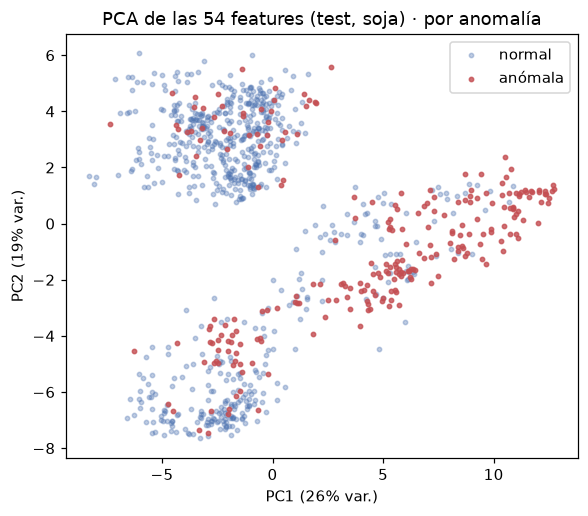

PC1+PC2 explican solo 45% de la varianza


In [3]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42).fit(ds.X_test)
emb = pca.transform(ds.X_test)
v1, v2 = pca.explained_variance_ratio_[:2] * 100
fig, ax = plt.subplots(figsize=(6, 5))
for lab_, color, nombre in [(0, lab.C_NORMAL, "normal"), (1, lab.C_ANOM, "anómala")]:
    m = ds.y_test == lab_
    ax.scatter(emb[m,0], emb[m,1], s=8, alpha=0.35 if lab_==0 else 0.8, color=color, label=nombre)
ax.set_xlabel(f"PC1 ({v1:.0f}% var.)"); ax.set_ylabel(f"PC2 ({v2:.0f}% var.)")
ax.set_title("PCA de las 54 features (test, soja) · por anomalía"); ax.legend()
plt.show()
print(f"PC1+PC2 explican solo {v1+v2:.0f}% de la varianza")

El panorama es **matizado, y es justo lo que dice el techo**: una parte de las
anómalas (rojo) **se concentra a la derecha** (PC1 alto) — esa región es la **firma de
sequía**, las anomalías *detectables*; pero **muchas otras quedan mezcladas** entre las
normales, sin región propia — esas son las del techo estructural, sin firma climática. No
es "todo mezclado" ni "cluster limpio": es "una parte se separa, el resto no".

> **Dos advertencias honestas sobre este PCA** (por eso es ilustrativo; el argumento
> *fuerte* del techo es el cross-modelo de abajo):
> - **PC1+PC2 explican ~48%** de la varianza (lo imprime la celda): casi la mitad se pierde
>   al bajar a 2D, así que lo que se ve es una aproximación, no la geometría completa.
> - **Difiere del PCA del EDA** porque son datos distintos: acá es sobre `X_test` (test
>   ≥2021, normalizado por el pipeline con stats de train); en el EDA es sobre *todo* el
>   panel con otra normalización. El PCA se ajusta a los datos que ve → la proyección cambia.

## 5.2 · Cross-modelo: ¿todos fallan en las MISMAS?
Entrenamos varios modelos, marcamos el top-10% de cada uno, y contamos cuántas anomalías
las falla **todo el mundo**. Acá no comparamos *performance* (para eso reportamos media±std
en los otros nb) sino **qué muestras se escapan**: un modelo representativo por familia
(seed 42) alcanza — el solapamiento de errores es robusto a la semilla.

In [ ]:
modelos = {
    "IForest":  IsolationForestDetector(n_estimators=200, max_features=0.3).fit(ds.X_train),
    "OCSVM":    OneClassSVMDetector(kernel="rbf", nu=0.1).fit(ds.X_train),
    "AE":       AEDetector(hidden_dims=(64,32), latent_dim=16, max_epochs=200, random_state=42).fit(ds.X_train),
    "VAE":      VAEDetector(hidden_dims=(128,64), latent_dim=16, score_mode="recon_prob",
                            n_mc_samples=50, max_epochs=200, random_state=42).fit(ds.X_train),
}
# flag = marcada anómala (top-10% de su propio score)
flags = np.vstack([ (m.score_samples(ds.X_test) >=
                     np.quantile(m.score_samples(ds.X_test), 0.9)).astype(int)
                    for m in modelos.values()])
anom = ds.y_test == 1
falladas_por_todos = anom & (flags.sum(axis=0) == 0)   # anomalía que NADIE marca
print(f"anomalías reales: {anom.sum()}")
print(f"falladas por TODOS los modelos: {falladas_por_todos.sum()} "
      f"({100*falladas_por_todos.sum()/anom.sum():.0f}%)")

### ¿Qué tienen de distinto las falladas? Su clima
Comparamos la precipitación de verano (normalizada) de las anomalías detectadas vs las
falladas por todos:

In [5]:
prec_cols = [i for i,c in enumerate(ds.feature_cols) if "prectotcorr" in c]
precip_z = ds.X_test[:, prec_cols].mean(axis=1)         # firma de sequía (más negativo = más seco)
det_alguno = anom & (flags.sum(axis=0) > 0)
print(f"precip_z medio · detectadas por alguien: {precip_z[det_alguno].mean():+.2f}")
print(f"precip_z medio · falladas por todos    : {precip_z[falladas_por_todos].mean():+.2f}")

precip_z medio · detectadas por alguien: -0.84
precip_z medio · falladas por todos    : -0.47


Las **detectadas tienen sequía clara** (precip_z bien negativo); las **falladas tienen
clima casi normal**. No dejan huella en las features → ningún modelo puede verlas — es la
evidencia de que el techo es de señal, no de modelo.

## 5.3 · Conclusión
El techo es **estructural**: buena parte de las anomalías de rinde tienen causas no
climáticas (plaga, granizo, manejo) invisibles a las features climáticas — se ve en el PCA
(5.1, una parte de las anómalas no tiene región propia) y se confirma en el cross-modelo
(5.2: familias de modelos muy distintas fallan exactamente en las mismas muestras, y esas
muestras comparten un clima casi normal frente a las que sí se detectan, que tienen sequía
clara). No es la arquitectura (todos fallan igual), no es la etiqueta (la mayoría son
caídas de rinde reales) — es que la señal climática disponible no alcanza para explicar
una parte de las anomalías. La salida es **más señal**: el panel unificado ya suma estado
de suelo + verdor (NDVI/ERA5), que corren el techo un poco (aunque no lo rompen: seguimos
en ~0.6). El nb 6 chequea si las features agronómicas de dominio aportan algo más.